## **Librerias y Dependencias**

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

## **Parte I - 4p**
a) Construir una tabla con los cuatro valores de L y, para cada uno de ellos, los cuatro valores obtenidos del tiempo cronometrado de treinta oscilaciones, t. Obtener el valor medio del tiempo obtenido para cada longitud.
    
b) Hallar la incertidumbre de los tiempos anteriores, teniendo en cuenta el error aleatorio y el error sistemático de precisión.  
  
c) Expresar los correspondientes periodos, junto con sus incertidumbres absolutas y relativas, dividiendo el tiempo total entre el número de oscilaciones. Estimar la incertidumbre absoluta y relativa de cada una de las longitudes empleadas.  
  
d) Determinar g para las medidas de mayor y menor longitud, estimando su incertidumbre como medida indirecta a partir de los datos y las incertidumbres de T y de L.

### _a) Calculo de media_

In [23]:
n = 4
datos = {
    13:np.array([22.03,22.04,22.06,21.97]),
    40:np.array([38.07,38.35,38.09,38.22]),
    56:np.array([44.84,44.72,44.68,44.65]),
    64:np.array([48.38,48.19,48.37,48.56])
}

In [24]:
mean_vals = {
    13:0.,
    40:0.,
    56:0.,
    64:0.
}

for L,t_vals in datos.items():
    mean = np.mean(t_vals)
    mean_vals[L] = mean

    print(f"L: {L}cm --> Media: {mean:.3f}")


L: 13cm --> Media: 22.025
L: 40cm --> Media: 38.183
L: 56cm --> Media: 44.723
L: 64cm --> Media: 48.375


### _b) Calculo de incertudumbre_

Incertidumbre Sistematica para la Longitud: ± 0.5mm  
Incertidumbre Sistematica para el cronometro: ± 0.01s  
Incertidumbre Aleatoria: Tiempo de Reacción del humano

#### Calculo de Incertidumbre Humana

In [25]:
t_3 = 3.1825
Es_t = 0.01
Es_L = 0.05

std_vals = {
    13:0.,
    40:0.,
    56:0.,
    64:0.
}

Ea_vals = {
    13:0.,
    40:0.,
    56:0.,
    64:0.
}


In [26]:
for L,t_vals in datos.items():
    std = np.std(t_vals)
    E_a = (t_3)*(std/np.sqrt(n))
    std_vals[L] = std
    Ea_vals[L] = E_a
    print(f"L: {L}cm --> Desviacion Tipica: {std:.3g}")

L: 13cm --> Desviacion Tipica: 0.0335
L: 40cm --> Desviacion Tipica: 0.113
L: 56cm --> Desviacion Tipica: 0.0722
L: 64cm --> Desviacion Tipica: 0.131


In [27]:
E_t_total = {L:np.sqrt(Es_t**2 + E_a**2) for L,E_a in Ea_vals.items()}

In [28]:
for L in datos.keys():
    print(f"L: {L}cm --> Error Sistematico: ±{Es_t}s. Error Aleatorio: ±{Ea_vals[L]:.3g}s. Error Total: ±{E_t_total[L]:.3g}s")

L: 13cm --> Error Sistematico: ±0.01s. Error Aleatorio: ±0.0534s. Error Total: ±0.0543s
L: 40cm --> Error Sistematico: ±0.01s. Error Aleatorio: ±0.179s. Error Total: ±0.179s
L: 56cm --> Error Sistematico: ±0.01s. Error Aleatorio: ±0.115s. Error Total: ±0.115s
L: 64cm --> Error Sistematico: ±0.01s. Error Aleatorio: ±0.208s. Error Total: ±0.208s


In [29]:
print("Datos: ")
for L,mean_t in mean_vals.items():
    print(f"L: {L} ± {Es_L}cm  -->  Media t: {mean_t:.3f} ± {E_t_total[L]:.3g}s")

Datos: 
L: 13 ± 0.05cm  -->  Media t: 22.025 ± 0.0543s
L: 40 ± 0.05cm  -->  Media t: 38.183 ± 0.179s
L: 56 ± 0.05cm  -->  Media t: 44.723 ± 0.115s
L: 64 ± 0.05cm  -->  Media t: 48.375 ± 0.208s


### _c) Calculo del periodo_ 
$T = 2 \pi \sqrt{\frac{L}{g}}$

In [30]:
num_oscilaciones = 30

periodos = {L:t/num_oscilaciones for L,t in mean_vals.items()}
error_T = {L:E_t/num_oscilaciones for L,E_t in E_t_total.items()}

In [31]:
for L,T in periodos.items():
    print(f"L: {L}cm --> T:{T:.3g} ± {error_T[L]:.3g}s")

L: 13cm --> T:0.734 ± 0.00181s
L: 40cm --> T:1.27 ± 0.00598s
L: 56cm --> T:1.49 ± 0.00385s
L: 64cm --> T:1.61 ± 0.00695s


#### _Calculo de incertidumbres relativas y absolutas_

In [32]:
print("Incertidumbres de la Longitud: ")

for L in datos.keys():
    print(f"L = {L}cm: Absoluta: {Es_L}cm --> Relativa: {(Es_L/L)*100:.2f}%")

Incertidumbres de la Longitud: 
L = 13cm: Absoluta: 0.05cm --> Relativa: 0.38%
L = 40cm: Absoluta: 0.05cm --> Relativa: 0.12%
L = 56cm: Absoluta: 0.05cm --> Relativa: 0.09%
L = 64cm: Absoluta: 0.05cm --> Relativa: 0.08%


In [33]:
print("Incertidumbres del Periodo: ")

for L,T in periodos.items():
    print(f"T = {T:.3g}s: Absoluta: {error_T[L]:.3g}s --> Relativa: {(error_T[L]/T)*100:.2f}%")

Incertidumbres del Periodo: 
T = 0.734s: Absoluta: 0.00181s --> Relativa: 0.25%
T = 1.27s: Absoluta: 0.00598s --> Relativa: 0.47%
T = 1.49s: Absoluta: 0.00385s --> Relativa: 0.26%
T = 1.61s: Absoluta: 0.00695s --> Relativa: 0.43%


### d) _Calcular g de longitudes de mayor y menor longitud_

$T = 2\pi \sqrt{\frac{L}{g}} \rightarrow g = \frac{4\pi^2 L}{T^2}$

In [34]:
L_mayor = 64
L_menor = 13

g = lambda L,T: (4 * np.pi**2 * L)/(T**2)
g_mayor = g(L_mayor/100,periodos[L_mayor])
g_menor = g(L_menor/100,periodos[L_menor])

In [35]:
print(f"g(L = 64cm) ={g_mayor:.3g}m/s^2. g(L = 13cm) = {g_menor:.3g}m/s^2")

g(L = 64cm) =9.72m/s^2. g(L = 13cm) = 9.52m/s^2


## **Parte II - 4p**

a) Representar gráficamente $T^2$ frente a L.  
b) Ajustar los puntos experimentales anteriores a una recta por mínimos cuadrados, dando los valores de m y de c.  
c) Calcular la incertidumbre de la pendiente y de la ordenada en el origen, ∆𝑚 y ∆𝑐.  
d) Determinar el valor de g a partir de la pendiente de la recta obtenida. Hallar la incertidumbre de g.  

### _a) $T^2$ frente a L_

m: 3.9979324295839054. c: 0.0162404915660721. R^2: 0.9996420821633751


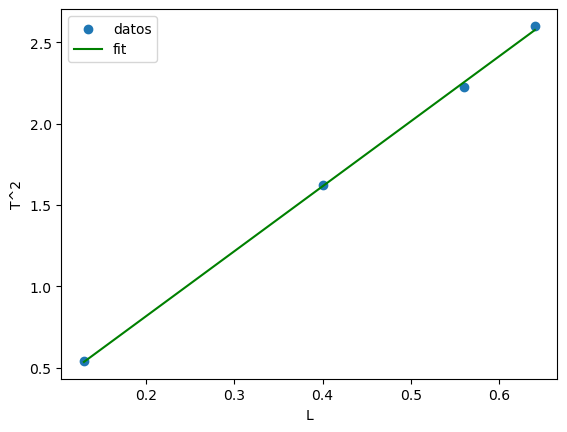

In [46]:
T_sq = np.array([T**2 for T in periodos.values()]).flatten()
L = np.array([L for L in periodos.keys()])/100

m_regress,c_regress,r_sq,p_val,error_g = linregress(L,T_sq)

print(f"m: {m_regress}. c: {c_regress}. R^2: {r_sq}")

plt.scatter(L,T_sq, label="datos")
plt.plot(L, m_regress*L + c_regress, label="fit", color="g")
plt.xlabel("L")
plt.ylabel("T^2")
plt.legend()
plt.show()

### _b) Recta por metodo de minimos cuadrados_

In [47]:
sum_x_sq = 0
sum_xy = 0

mean_x = np.mean(L)
mean_y = np.mean(T_sq)

for i in range(n):
    sum_xy += L[i]*T_sq[i]
    sum_x_sq += L[i]**2

E = sum_xy - (n*mean_x*mean_y)
D = sum_x_sq - (n*mean_x**2)

m = E/D

c = mean_y - (m*mean_x)
print(f"E={E}, D = {D} m: {m}. c: {c}.")


E=0.6071859877430557, D = 0.1518750000000001 m: 3.997932429583903. c: 0.01624049156607299.


### _c) Incertidumbre de m y c_

Nivel de Confianza: 95%

$s_{res}^2 = \frac{1}{n-2} \sum_{i=1}^n (Y_i - mX_i -c)^2$

In [48]:
t_2 = 4.0327
sum_sres = 0
for i in range(n):
    sum_sres += (T_sq[i] - m*L[i] -c)**2

sres = (1/(n-2))*sum_sres

$s_m^2 = \frac{s_{res}^2}{D}$  
$s_c^2 = s_{res}^2(\frac{1}{n} + \frac{\bar{X}^2}{D})$

In [49]:
s_m = sres/D
s_c = sres*(1/n + (mean_x**2)/D)

print(f"s^2_res={sres:.3e}. s^2_m = {s_m:.3e}, s^2_c = {s_c:.3e}")

s^2_res=8.693e-04. s^2_m = 5.724e-03, s^2_c = 1.288e-03


$\Delta m = t_{n-2}·s_m$  
$\Delta c = t_{n-2}·s_c$  

In [50]:
delta_m = t_2 * s_m
delta_c = t_2 * s_c

print(f"Δm = {delta_m:.2e}, Δc = {delta_c:.2e}")

Δm = 2.31e-02, Δc = 5.19e-03


### _d) g a partir de la pendiente_

$g = \frac{4\pi^2 L}{T^2} \rightarrow g = 4\pi^2 \frac{1}{pendiente}$

Por Propagacion de Errores: $\Delta g = |\frac{dg}{dm}|\Delta m$ con:  
$\frac{dg}{dm} = -\frac{4\pi^2}{m^2}$

In [51]:
g = (4 * np.pi**2)/m
delta_g = ((4*np.pi**2)/m**2)*delta_m
print(f"g = {g:.2e} ± {delta_g:.5f} m/s^2")

g = 9.87e+00 ± 0.05701 m/s^2


## **Parte 3 - 1p**
Discutir los resultados obtenidos, comparando los valores de g y sus incertidumbres obtenidos en las partes I y II, así como su diferencia con el valor asumido normalmente para la gravedad.